# ECS659U - Coursework


* The **goal** of the CW is similar to that of Week 2's Lab: fitting a curve to data, also known as **curve fitting**.
* This has applications in many different disciplines that make use of AI: FinTech, Physics Modelling, or even Sports.
* For example, we might be interested in learning the evolution (over time) of the price of a specific product in different countries. This can depend on several factors: the product itself, the country, the initial value of the product's price, etc.
* As usual, we are interested in learning a model that finds these relationships *from the data*.


## Learning a set of functions

* The main difference with Week 2's Lab that we will train a network that does not learn a single function but a set of functions.
* You are provivided with a training set ("train_data.csv") containing 30,000 functions. Each function has $100$ points (N_x = 100) on the x-axis from a $[-1, 1]$ distribution.
* Because we are dealing with a family of functions and not just a single function, our model must be able to perform two tasks: *Function Selection* and *Regression*.
* Function selection means that given some *additional* input (to be defined below) the model somehow must choose which function from the set of functions it needs to model.
* Once the correct function is picked then the model must perform regression i.e. learn the input-output relationship $y=f_a(x)$ where $f_a$ is the selected function.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

%cd /content/drive/MyDrive/CW

Mounted at /content/drive
/content/drive/MyDrive/CW


In [2]:
import torch
from torch.utils.data import TensorDataset, DataLoader
import numpy as np

y_train = np.loadtxt('train_data.csv', delimiter=',')
N_train, Nx = y_train.shape
x_train = np.tile(np.linspace(-1, 1, Nx), (N_train, 1))
x_tensor = torch.from_numpy(x_train).float()
y_tensor = torch.from_numpy(y_train).float()
train_loader = DataLoader(TensorDataset(x_tensor, y_tensor),batch_size=128,shuffle=True)

y_test = torch.from_numpy(np.loadtxt('test_data.csv', delimiter=',')).float()
x_test = torch.linspace(-1, 1, 100).unsqueeze(0).repeat(300, 1)

# Load the context bundle
test_contexts = torch.load('test_observations.pt')


## The Learning Objective


* For both *training and testing*, a random subset of $N$ pairs $(x_o, y_o)$ (which is called observed data) is provided. This acts as prior information to help the model identify which specific function is looking at.

* The model will take the observed pairs $(x_o, y_o)$ and target values $x_t$ and will produce the estimated values $\hat{y}_t$. The ultimate goal is to estimate the function corresponding to the curve that observed pairs $(x_o, y_o)$ belong to and then estimate the output value $\hat{y}_t$ corresponding to $x_t$. During training we have access to the ground-truth values $y_t$, and thus we can compute a loss between the model's predictions $\hat{y}_t$ and the ground-truth values $y_t$.  


## The Model Architecture

* Our model consists of 2 MLPs which must be jointly trained. Specifically, you should implement the following architecture:
* *Encoder*: The first MLP is called the Encoder. It takes as input the random set of $N$ observed pairs $(x_o, y_o)$  and maps each of them (through a series of hidden layers) to a feature vector of dimension $h_{dim}$. A final layer produces the latent feature representation $r_o$ of dimension $r_{dim}$.
* A total observed feature is produced by summing or averaging over all features (e.g., $r_O=\frac{1}{N}\sum_o r_o$).
* *Decoder*: The second MLP is called the Decoder. It takes as input the $r_O$ and each input data $x_t$. The Decoder (through a series of hidden layers) maps the pair $(r_O, x_t)$ to some feature vector of dimension $h_{dim}$. A final layer will produce the model's prediction $\hat{y}_t$ (corresponding to the input $x_t$).
* Hint! Try different choices for the number of hidden layers in the MLPs and for the hidden dimension $h_{dim}$.


## Tasks

* You have to implement the following:
    1. Create the model based on the provided architecture description. $r_{dim}$ should be a configurable hyperparameter. (20%)
    2. Create the optimizer and the loss function. Write the training script that will train the model and print the training loss. (20%)
    3. Train three versions of the model, called model2, model4, model8, by only alternating the dimension of the latent representation $r_{dim}$ to be 2, 4, and 8, respectively. Using the provided test_data.csv and the observation pairs provided in test_observations.pt, calculate the average error for each model. Provide results for all these calculations in your report. (30%)
    4.  Given you results, which latent representation ( $r_{dim}$ ) yielded the best results and which latent representation ($r_{dim}$) offered the  most significant improvement? How many independent variables were used to generate the training and test data? Provide explanation. (20%)
    5. For $r_{dim}$ which offered the most improvement, how capable your model was in terms of disentagling the independent variables? Hint: check the correlations between the dimensions of the latent representation. Provide explanation. (10%)

# Notes
**xi yi** Training examples, input and output of a function

**Latent Representation**
Shows information about function, like slope, intercept

**Latent Vector Size**
r_dim - if its 2 then the vector has 2 numbers in it - [0.2, 0.3]

**Encoder output**
example take mean(all ri), output single r,

decoder will use this to predict new y value. ri = encoder(xi, yi)

In [3]:
# Imports
from torch import nn

In [4]:
# Helper function for weights
def init_weights(m):
  if isinstance(m, nn.Linear):
    torch.nn.init.normal_(m.weight, std=0.01)
    torch.nn.init.zeros_(m.bias)

The below MLP class will make every mlp have 2 hidden layers

Each hidden layer will have 64 neurons

After each hidden layer, the relu funciton will be applied to the output

In [5]:
# MLP Classx

class Net(torch.nn.Module):
  def __init__(self, num_inputs, num_outputs):
    super(Net, self).__init__()
    self.num_inputs = num_inputs
    self.num_outputs = num_outputs
    num_hidden = 64

    self.Linear1 = nn.Linear(num_inputs, num_hidden)
    self.Linear2 = nn.Linear(num_hidden, num_hidden)
    self.Linear3 = nn.Linear(num_hidden, num_outputs)

  def forward(self, x):
    out = torch.relu(self.Linear1(x))
    out = torch.relu(self.Linear2(out))
    out = self.Linear3(out)
    return out



# Implement the encoder and decoder MLPs
*   Each should have configurable number of input and output dimensions

**Encoder**
Transforms the input data to a latent output vector for the decoder to use
1.   Takes context set as input: xi yi pairs
2.   Maps each pair to a latent representation vector ri
3.   Take average of representations to show single context representation


**Decoder**
Uses latent representation of the data, and the new input that we want a prediction for

In [6]:
class CombinedModel(nn.Module):
  def __init__(self, x_dim, y_dim, r_dim):
    super().__init__()

    # Encoder
    self.encoder = Net(
        num_inputs = x_dim + y_dim,
        num_outputs = r_dim
    )

    # Decoder
    self.decoder = Net(
        num_inputs = x_dim + r_dim,
        num_outputs = y_dim
    )

  def forward(self, x_context, y_context, x_target):
    # Concatenate the columns of x and y, for each context point
    # Shape - [batch size, n context, x dim + y dim]
    # Number of rows stay the same, the columns were just added together
    xy = torch.cat([x_context, y_context], dim=-1)

    # We calculate rows of r_i, and take the average
    # We want one value per column for the aggregated r vector
    r_i = self.encoder(xy)

    # So average accross context point dimension
    # Gives one latent vector per function
    r = torch.mean(r_i, dim=1)

    # Repeat each function representation across all target points
    r = r.unsqueeze(1)
    r = r.repeat(1, x_target.shape[1], 1)

    # Put the x values together with the r values,
    # x defines where we want to evaluate the function
    # r values are describing the function
    decoder_input = torch.cat([x_target, r], dim=-1)
    y_pred = self.decoder(decoder_input)

    return y_pred

# Setting up the training process

**Optimiser**
Set up optimiser, using SGD (Stoachastic Gradient Descent) with learning rate and weight decay

**Loss Function**
Measure difference between true outputs and predicted outputs. Use MSE or Cross Entropy Loss

**Training Loop**
*   Each iteration, sample a function from training set.
*   Split observations
*   Context set: observed points used to infer function
*   Target set: points the model must predict
*   Pass (x, y) through encoder
*   Produce ri, and compute the aggregated mean
*   Decode predictions, combine r with target prediction xt
*   Compute loss with the predicted y hat t with true yt
*   Backpropagation, compute gradients and optimiser update network weights



In [7]:
 def train_model(model, train_loader, epochs, learning_rate):
  wd = 0
  optimiser = torch.optim.SGD(model.parameters(), lr=learning_rate, weight_decay=wd)
  loss_f = nn.MSELoss()

  model.train()

  losses_arr = []

  for epoch in range(epochs):

    epoch_loss = 0

    for x_batch, y_batch in train_loader:

      # Ensure the points are treated as 1D input/output
      x_batch = x_batch.unsqueeze(-1)
      y_batch = y_batch.unsqueeze(-1)

      # Use first n as the context points
      n_context = 10
      x_c = x_batch[:, :n_context, :]
      y_c = y_batch[:, :n_context, :]
      # Use all points as targets


      # Ensure the gradients from previous step are cleared
      # so that only the current batch contributes to the update
      optimiser.zero_grad()

      # Model predicts target y values from the context set and target x values
      # Compare the predictions with the true target y values
      y_pred = model(x_c, y_c, x_batch)
      loss = loss_f(y_pred, y_batch)

      loss.backward()
      optimiser.step()

      epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader)
    print("Epoch:", epoch, "Total Loss:", epoch_loss, "Avg Loss:", avg_loss)
    losses_arr.append(avg_loss)

  return losses_arr

Initialise model, train,

In [8]:
model_2 = CombinedModel(x_dim=1, y_dim=1, r_dim=2)
arr_2 = train_model(model_2, train_loader, epochs=50, learning_rate = 0.01)

Epoch: 0 Total Loss: 130.23176139593124 Avg Loss: 0.5541777080677925
Epoch: 1 Total Loss: 97.24373126029968 Avg Loss: 0.4138031117459561
Epoch: 2 Total Loss: 81.92115539312363 Avg Loss: 0.3486006612473346
Epoch: 3 Total Loss: 78.48277901113033 Avg Loss: 0.3339692723877887
Epoch: 4 Total Loss: 77.09583348035812 Avg Loss: 0.3280673765121622
Epoch: 5 Total Loss: 76.48551404476166 Avg Loss: 0.32547027253090066
Epoch: 6 Total Loss: 75.9534273147583 Avg Loss: 0.32320607367982257
Epoch: 7 Total Loss: 75.70766353607178 Avg Loss: 0.3221602703662629
Epoch: 8 Total Loss: 75.36646524071693 Avg Loss: 0.32070836272645503
Epoch: 9 Total Loss: 75.20287331938744 Avg Loss: 0.3200122268910104
Epoch: 10 Total Loss: 75.03821055591106 Avg Loss: 0.3193115342804726
Epoch: 11 Total Loss: 74.88555558025837 Avg Loss: 0.3186619386393973
Epoch: 12 Total Loss: 74.78145590424538 Avg Loss: 0.31821896129466115
Epoch: 13 Total Loss: 74.63453827798367 Avg Loss: 0.3175937799063135
Epoch: 14 Total Loss: 74.58464905619621 

In [9]:
model_4 = CombinedModel(x_dim=1, y_dim=1, r_dim=4)
arr_4 = train_model(model_4, train_loader, epochs=50, learning_rate = 0.01)

Epoch: 0 Total Loss: 131.1998462677002 Avg Loss: 0.5582972181604263
Epoch: 1 Total Loss: 105.99358531832695 Avg Loss: 0.4510365332694764
Epoch: 2 Total Loss: 83.46155700087547 Avg Loss: 0.35515556170585305
Epoch: 3 Total Loss: 79.8052788078785 Avg Loss: 0.3395969310973553
Epoch: 4 Total Loss: 77.9505832195282 Avg Loss: 0.33170460944480085
Epoch: 5 Total Loss: 77.00259467959404 Avg Loss: 0.327670615657847
Epoch: 6 Total Loss: 76.41429916024208 Avg Loss: 0.3251672304691152
Epoch: 7 Total Loss: 76.03777016699314 Avg Loss: 0.32356497943401336
Epoch: 8 Total Loss: 75.71252270042896 Avg Loss: 0.3221809476613998
Epoch: 9 Total Loss: 75.50106540322304 Avg Loss: 0.3212811293754172
Epoch: 10 Total Loss: 75.214202105999 Avg Loss: 0.3200604344936127
Epoch: 11 Total Loss: 75.1704113483429 Avg Loss: 0.3198740908440123
Epoch: 12 Total Loss: 74.95148178935051 Avg Loss: 0.31894247569936385
Epoch: 13 Total Loss: 74.84059922397137 Avg Loss: 0.31847063499562284
Epoch: 14 Total Loss: 74.74119339883327 Avg 

In [10]:
model_8 = CombinedModel(x_dim=1, y_dim=1, r_dim=8)
arr_8 = train_model(model_8, train_loader, epochs=50, learning_rate = 0.01)

Epoch: 0 Total Loss: 126.37225663661957 Avg Loss: 0.5377542835600833
Epoch: 1 Total Loss: 92.81801956892014 Avg Loss: 0.394970296037958
Epoch: 2 Total Loss: 82.9343663752079 Avg Loss: 0.35291219734131024
Epoch: 3 Total Loss: 79.99628311395645 Avg Loss: 0.3404097153785381
Epoch: 4 Total Loss: 78.30079631507397 Avg Loss: 0.33319487793648495
Epoch: 5 Total Loss: 77.33889284729958 Avg Loss: 0.3291016716906365
Epoch: 6 Total Loss: 76.75642210245132 Avg Loss: 0.32662307277638863
Epoch: 7 Total Loss: 76.43940901756287 Avg Loss: 0.32527408092579946
Epoch: 8 Total Loss: 76.01766994595528 Avg Loss: 0.3234794465785331
Epoch: 9 Total Loss: 75.74898958206177 Avg Loss: 0.3223361258811139
Epoch: 10 Total Loss: 75.50029836595058 Avg Loss: 0.32127786538702374
Epoch: 11 Total Loss: 75.31482622027397 Avg Loss: 0.3204886222139318
Epoch: 12 Total Loss: 75.14061333239079 Avg Loss: 0.319747290776131
Epoch: 13 Total Loss: 74.97779139876366 Avg Loss: 0.3190544314841007
Epoch: 14 Total Loss: 74.84895254671574 A

Text(0, 0.5, 'Loss')

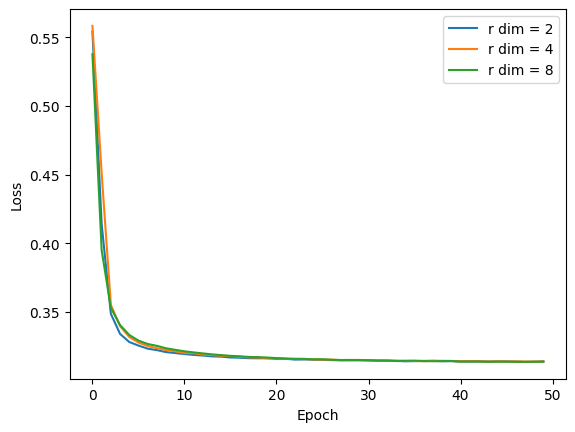

In [11]:
import matplotlib.pyplot as plt
plt.plot(arr_2, label = 'r dim = 2')
plt.plot(arr_4, label = 'r dim = 4')
plt.plot(arr_8, label = 'r dim = 8')
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Loss")

Text(0.5, 1.0, 'Training Loss (Zoomed)')

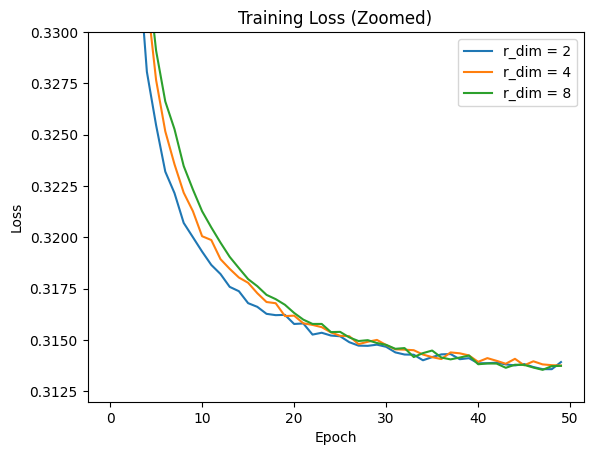

In [12]:
plt.figure()
plt.plot(arr_2, label="r_dim = 2")
plt.plot(arr_4, label="r_dim = 4")
plt.plot(arr_8, label="r_dim = 8")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.ylim(0.312, 0.330)
plt.legend()
plt.title("Training Loss (Zoomed)")

## Model Evaluation

After training, each model is evaluated on unseen test data to measure how well it generalises.
The evaluation process uses the same structure as training but without updating model parameters.

* The test set contains 300 functions with 100 points each, the same format as training
* A context set of 10 observed points is provided to the model as a "hint" to identify which function it is looking at
* The model then predicts y values for all 100 target x values and the MSE is computed against the true values
* A lower error means the model was better at generalising to unseen functions


In [24]:
# This function tests how well a trained model performs on unseen data
# It takes the model, the test x and y values, and the context observations
# The context observations act as the "hint" for which function the model is looking at

def evaluate_model(model, x_test, y_test, context):
    model.eval()
    with torch.no_grad():

        # Add an extra dimension so each value is treated as a 1D input/output
        # Shape goes from [300, 100] to [300, 100, 1]
        x_t = x_test.unsqueeze(-1)
        y_t = y_test.unsqueeze(-1)

        # Context is already 3D [300, 10, 1] so no unsqueeze needed
        x_c = context['x']
        y_c = context['y']

        # Run the model: encode the context, then decode predictions for all target x values
        y_pred = model(x_c, y_c, x_t)

        # Compute the average squared error between predictions and true values
        loss = nn.MSELoss()(y_pred, y_t)

    return loss.item()

In [27]:
# Run the evaluate function on each of the three models using the 10_stride1 context set
# A lower error means the model was better at predicting unseen functions

context = test_contexts['10_stride1']

print("model_2 error:", evaluate_model(model_2, x_test, y_test, context))
print("model_4 error:", evaluate_model(model_4, x_test, y_test, context))
print("model_8 error:", evaluate_model(model_8, x_test, y_test, context))

model_2 error: 0.2899734377861023
model_4 error: 0.29039400815963745
model_8 error: 0.2898005247116089


## Analysis

**Which r_dim gave the best (lowest) test error?**


model_8 achieved the lowest test error of 0.2898, however the differences between all three models were very small, suggesting that even r_dim=2 captures most of the information needed.

**Which r_dim showed the most improvement?**


The most significant improvement was from r_dim=4 to r_dim=8, as model_4 performed slightly worse than model_2, before model_8 recovered to the best result.

**How many independent variables were used to generate the data?**


The data was likely generated from 2 independent variables. This is supported by the fact that model_2 (with only 2 dimensions) performs nearly as well as model_8. This suggests r_dim=2 is already sufficient to represent the underlying functions.

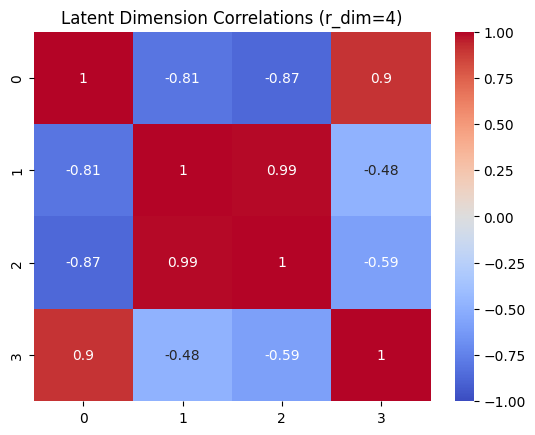

In [28]:
import seaborn as sns

# Extract the latent representations from model_4 on the test context set
# We pass the context points through the encoder and average to get one r vector per function

model_4.eval()
with torch.no_grad():
    x_c = context['x']
    y_c = context['y']

    # Pass context pairs through the encoder to get r_i for each point
    xy = torch.cat([x_c, y_c], dim=-1)
    r_i = model_4.encoder(xy)

    # Average across context points to get one latent vector per function
    # Shape: [300, 4]
    r = torch.mean(r_i, dim=1)

# Convert to numpy and compute the correlation matrix between the 4 latent dimensions
r_np = r.numpy()
corr = np.corrcoef(r_np.T)

# Plot the correlation matrix as a heatmap
# Values close to 0 mean the dimensions are uncorrelated (disentangled)
plt.figure()
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Latent Dimension Correlations (r_dim=4)")
plt.show()

### Latent Dimension Correlations

The heatmap shows the correlation between each pair of the 4 latent dimensions in model_4.

The key finding is that dimensions 1 and 2 are very highly correlated (0.99), meaning they are capturing almost identical information. This suggests the model has not fully disentangled the underlying independent variables into separate dimensions.

Dimensions 0 and 3 appear to be capturing somewhat different information, but still show strong correlations with the other dimensions (0.9, -0.81, -0.87, -0.59).

Overall, the high correlations across all dimensions suggest the model is struggling to disentangle the 2 independent variables into separate latent dimensions.
Ideally we would expect to see correlations close to 0 between dimensions if the model had successfully separated the underlying factors that generated the data.